In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [4]:
df['Дата'] = pd.to_datetime(df['Дата'])

In [5]:
print(df['Дата'].dtype)

datetime64[ns]


Сгруппируйте данные по дате, посчитайте количество продаж

In [6]:
grouped_df = df.groupby('Дата').size().reset_index(name='Количество продаж')

Вывести несколько первых строк сгруппированных данных

In [7]:
print(grouped_df.head())

        Дата  Количество продаж
0 2018-01-04               1840
1 2018-01-05               1301
2 2018-01-06               1306
3 2018-01-07               1322
4 2018-01-09               1719


Нарисуйте график продаж у `grouped_df`

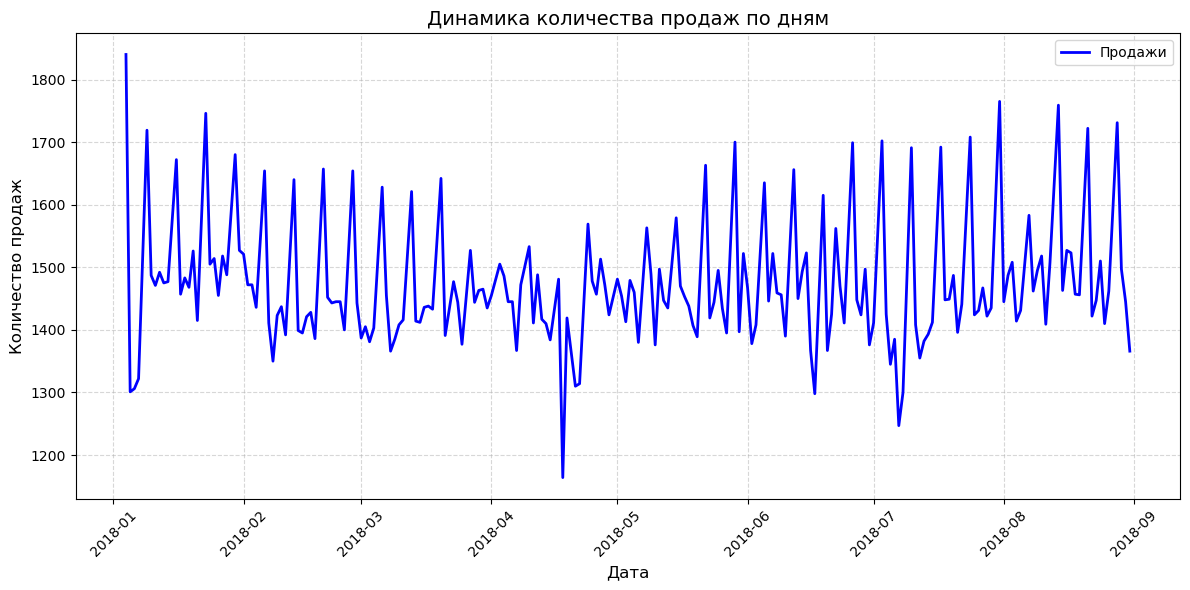

In [83]:
plt.figure(figsize=(12, 6))
plt.plot(grouped_df['Дата'], grouped_df['Количество продаж'], color='blue', linewidth=2, label='Продажи')

plt.title('Динамика количества продаж по дням', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество продаж', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

График отображает динамику количества продаж по дням за период с 4 января 2018 года по 31 августа 2018 года.

В целом, на протяжении всего периода базовый уровень ежедневных продаж стабилен и колеблется в коридоре от 1300 до 1800 операций в день, глобальные тренды на рост или падение отсутствуют.

На графике продаж четко видна регулярная недельная сезонность. Линия графика постоянно колеблется вверх-вниз с одинаковым шагом. Это говорит о том, что активность продаж строго привязана к дням недели (будни/выходные).

На графике выделяется критически важная аномалия это мощный нисходящий выброс (провал) в середине апреля 2018 года. Продажи падают практически до нуля, это указывает скорее на разовый форс-мажор.

Анализ данных по строке с максимальным выбросом по количеству продаж указывает на то, что 28 июня 2018 года зафиксирована странная активность - единичная продажа топового товара product_0 контрагенту address_208 в размере сразу 200 единиц, при этом общее число продаж в этот период среднее. Это может указывать на технический сбой в системе учета в конце месяца или проведение крупной оптовой сделки вместо стандартной розницы.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [81]:
if 'Количество' in df.columns:
    max_outlier = df[df['Количество'] == df['Количество'].max()]
else:
    max_day = grouped_df[grouped_df['Количество продаж'] == grouped_df['Количество продаж'].max()]
    max_outlier = df[df['Дата'] == max_day['Дата'].values[0]]

print("Строка с максимальным выбросом:")
print(max_outlier)

Строка с максимальным выбросом:
             Дата  Склад   Контрагент Номенклатура  Количество  Месяц  \
218822 2018-06-28      1  address_208    product_0         200      6   

        День_недели  
218822            3  


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [82]:
df['Месяц'] = df['Дата'].dt.month
df['День_недели'] = df['Дата'].dt.dayofweek

filtered_df = df[(df['Склад'] == 3) & (df['Месяц'].isin([6, 7, 8])) & (df['День_недели'] == 2)]

top_product = filtered_df.groupby('Номенклатура')['Количество'].sum().sort_values(ascending=False)

print("Топовый товар по средам за лето у 3-го склада:")
print(top_product.head(1))

Топовый товар по средам за лето у 3-го склада:
Номенклатура
product_1    2267
Name: Количество, dtype: int64


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [68]:
weather = pd.read_csv('weather_astana.csv', sep=';', encoding='utf-8')

In [69]:
weather.columns = weather.columns.str.strip()

In [70]:
weather = weather.reset_index()

In [71]:
weather = weather.rename(columns={'index': 'Дата_время_строка'})

In [72]:
weather['Дата_время'] = pd.to_datetime(weather['Дата_время_строка'], format='%d.%m.%Y %H:%M', errors='coerce')

In [73]:
weather['Дата'] = weather['Дата_время'].dt.normalize()

In [74]:
weather['T'] = pd.to_numeric(weather['T'], errors='coerce')

In [75]:
daily_temp = weather.groupby('Дата')['T'].mean().reset_index()

In [76]:
grouped_df['Дата'] = pd.to_datetime(grouped_df['Дата']).dt.normalize()

In [77]:
merged_df = pd.merge(grouped_df, daily_temp, on='Дата', how='inner')

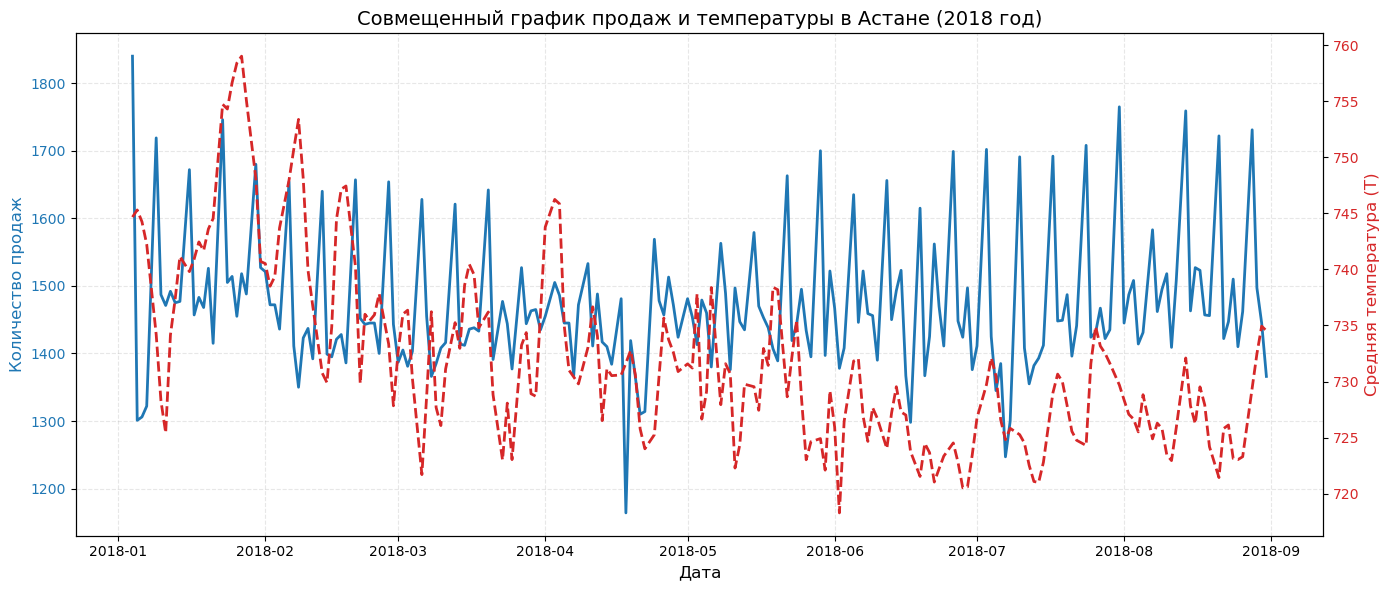

In [78]:
fig, ax1 = plt.subplots(figsize=(14, 6))

color = 'tab:blue'
ax1.set_xlabel('Дата', fontsize=12)
ax1.set_ylabel('Количество продаж', color=color, fontsize=12)
ax1.plot(merged_df['Дата'], merged_df['Количество продаж'], color=color, linewidth=2, label='Продажи')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.3)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Средняя температура (T)', color=color, fontsize=12)
ax2.plot(merged_df['Дата'], merged_df['T'], color=color, linestyle='--', linewidth=2, label='Температура')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Совмещенный график продаж и температуры в Астане (2018 год)', fontsize=14)
fig.tight_layout()
plt.show()

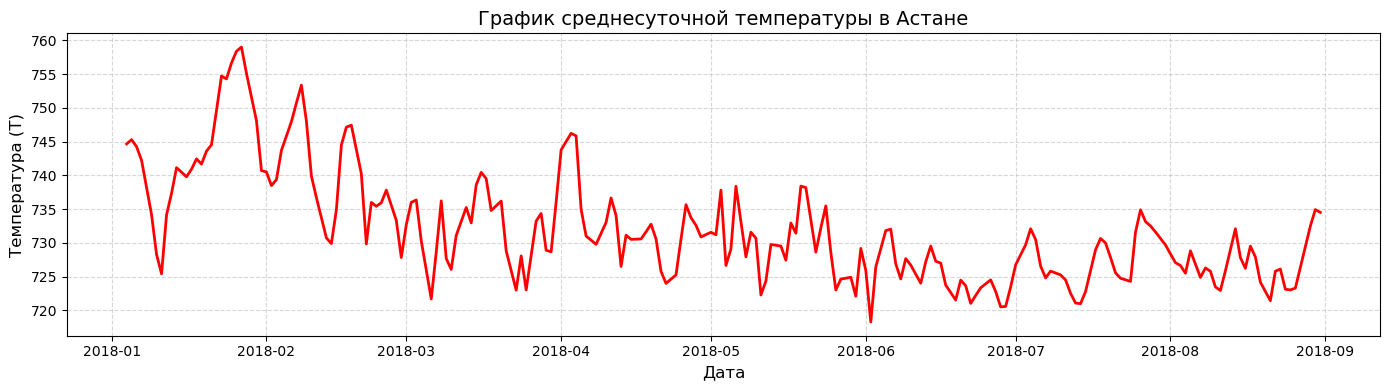

In [79]:
plt.figure(figsize=(14, 4))
plt.plot(merged_df['Дата'], merged_df['T'], color='red', linewidth=2)
plt.title('График среднесуточной температуры в Астане', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Температура (T)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()